# Teil: 2 Mobile Game Analyse

Data Analytics Project 2026 
Yasemin Senel 

In diesem Projekt werden zwei Datensätze analysiert:

1. **17k_strategy_games.csv**
2. **Highest_Grossing_Mobile_Game.csv**

## Ziel des Projekts
Ziel ist es, die Struktur und Eigenschaften von Mobile Games zu untersuchen und folgende Fragen zu beantworten:
Die beiden Datensätze werden über normalisierte Spielnamen gemerged, da kein gemeinsamer Primärschlüssel vorhanden ist.

### Strategy Games
- Rating-Verteilung
- Reviews vs Rating
- Preisstruktur - kostenlos vs kostenpflichtig
- Top Developer nach Anzahl Spiele
### Top Grossing Games
- Genres im Grossing-Datensatz
- Erfolgreichste Publisher/Developer
### Merge-Analyse
- Welche Strategy Games sind auch in Highest Grossing
- Vergleich Highest-Grossing-Strategy-Games vs restliche Strategy Games
- Durchschnittsrating: Anteil kostenlos und mit IAP

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown
import ipywidgets as widgets
from ipywidgets import interact
import ast


# Bereinigte Datensätze einlesen

In [2]:
strategy = "Datensatz/17k_strategy_games_cleaned.csv"
grossing = "Datensatz/Highest_Grossing_Mobile_Game_cleaned.csv"
strategy = pd.read_csv(strategy)
grossing = pd.read_csv(grossing)

In [3]:
print("Shape Strategy Games:", strategy.shape)
print("Shape Highest Grossing:", grossing.shape)

Shape Strategy Games: (16847, 30)
Shape Highest Grossing: (104, 11)


In [4]:
display(Markdown("## Erste Übersicht der bereinigten Datensätze"))

display(Markdown("### Strategy Games"))
display(strategy.head())

display(Markdown("### Highest Grossing"))
display(grossing.head())

## Erste Übersicht der bereinigten Datensätze

### Strategy Games

,url,id,name,subtitle,icon_url,average_user_rating,user_rating_count,price,in_app_purchases,description,...,has_in_app_purchases,in_app_purchase_count,min_in_app_purchase,max_in_app_purchase,avg_in_app_purchase,language_count,genre_count,price_is_valid,size_is_valid,rating_is_valid
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,0,"Join over 21,000,000 of our fans and download ...",...,False,0,NaN,NaN,NaN,17,3,True,True,True
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,0,"The classic game of Reversi, also known as Oth...",...,False,0,NaN,NaN,NaN,1,3,True,True,True
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,0,Play the classic strategy game Othello (also k...,...,False,0,NaN,NaN,NaN,1,3,True,True,True
3,https://apps.apple.com/us/app/sudoku-free/id28...,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,190394.0,0.00,0,"Top 100 free app for over a year.\nRated ""Best...",...,False,0,NaN,NaN,NaN,17,3,True,True,True
4,https://apps.apple.com/us/app/senet-deluxe/id2...,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.5,28.0,2.99,0,"""Senet Deluxe - The Ancient Game of Life and A...",...,False,0,NaN,NaN,NaN,15,4,True,True,True


### Highest Grossing

,game,revenue,initial_release,publisher_s,genre_s,publisher_list,genre_list,publisher_count,genre_count,revenue_usd_billions,revenue_is_valid
0,Honor of Kings / Arena of Valor,14667500000,2015-11-26,Tencent Games,MOBA,['Tencent Games'],['MOBA'],1,1,14.66750,True
1,Monster Strike,10000000000,2013-08-08,Mixi,Puzzle / RPG / Strategy,['Mixi'],"['Puzzle', 'RPG', 'Strategy']",1,3,10.00000,True
2,PUBG Mobile,9000000000,2018-03-19,Tencent Games / Krafton / VNG Games,Battle royale,"['Tencent Games', 'Krafton', 'VNG Games']",['Battle royale'],3,1,9.00000,True
3,Puzzle & Dragons,8578340000,2012-02-20,GungHo Online Entertainment,RPG / Puzzle,['GungHo Online Entertainment'],"['RPG', 'Puzzle']",1,2,8.57834,True
4,Clash of Clans,8000000000,2012-08-02,Supercell (Tencent),Strategy,['Supercell (Tencent)'],['Strategy'],1,1,8.00000,True


In [5]:
strategy= strategy.drop(columns = "url")
strategy= strategy.drop(columns = "id")
strategy= strategy.drop(columns = "description")

In [6]:
strategy

,name,subtitle,icon_url,average_user_rating,user_rating_count,price,in_app_purchases,developer,age_rating,languages,...,has_in_app_purchases,in_app_purchase_count,min_in_app_purchase,max_in_app_purchase,avg_in_app_purchase,language_count,genre_count,price_is_valid,size_is_valid,rating_is_valid
0,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,0,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",...,False,0,NaN,NaN,NaN,17,3,True,True,True
1,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,0,Kiss The Machine,4+,EN,...,False,0,NaN,NaN,NaN,1,3,True,True,True
2,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,0,Bayou Games,4+,EN,...,False,0,NaN,NaN,NaN,1,3,True,True,True
3,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,190394.0,0.00,0,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",...,False,0,NaN,NaN,NaN,17,3,True,True,True
4,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.5,28.0,2.99,0,RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU...",...,False,0,NaN,NaN,NaN,15,4,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16842,Stack Puzzle : Rise Tower,"Blast the cubes, solve puzzle!",https://is5-ssl.mzstatic.com/image/thumb/Purpl...,0.0,0.0,0.00,0,Zhigang Pei,4+,EN,...,False,0,NaN,NaN,NaN,1,4,True,True,True
16843,EachOther,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,0.0,0.0,0.00,0,Sultan Shindi,4+,EN,...,False,0,NaN,NaN,NaN,1,3,True,True,True
16844,Rabbit Vs Tortoise,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,0.0,0.0,0.00,0,Vishal Baldha,4+,EN,...,False,0,NaN,NaN,NaN,1,2,True,True,True
16845,FaTaLL,Most fun game!!!,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,0.0,0.0,0.00,"9.99, 49.99, 3.99",Tayrem Games,4+,EN,...,True,3,3.99,49.99,21.323333,1,3,True,True,True


In [7]:
display(Markdown("## Strategy Games"))
print(strategy.info())
display(Markdown("### Fehlende Werte"))
display(strategy.isna().sum().sort_values(ascending=False).to_frame("missing_values").head(15))

display(Markdown("## Highest Grossing"))
print(grossing.info())
display(Markdown("### Fehlende Werte"))
display(grossing.isna().sum().sort_values(ascending=False).to_frame("missing_values").head(15))

## Strategy Games

<class 'pandas.DataFrame'>
RangeIndex: 16847 entries, 0 to 16846
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   name                          16847 non-null  str    
 1   subtitle                      5212 non-null   str    
 2   icon_url                      16847 non-null  str    
 3   average_user_rating           16847 non-null  float64
 4   user_rating_count             16847 non-null  float64
 5   price                         16823 non-null  float64
 6   in_app_purchases              16847 non-null  str    
 7   developer                     16847 non-null  str    
 8   age_rating                    16847 non-null  str    
 9   languages                     16787 non-null  str    
 10  size                          16846 non-null  float64
 11  primary_genre                 16847 non-null  str    
 12  genres                        16847 non-null  str    
 13  original_rel

### Fehlende Werte

,missing_values
subtitle,11635
avg_in_app_purchase,9232
max_in_app_purchase,9232
min_in_app_purchase,9232
languages,60
price,24
size,1
size_mb,1
name,0
in_app_purchase_list,0


## Highest Grossing

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   game                  104 non-null    str    
 1   revenue               104 non-null    int64  
 2   initial_release       104 non-null    str    
 3   publisher_s           104 non-null    str    
 4   genre_s               104 non-null    str    
 5   publisher_list        104 non-null    str    
 6   genre_list            104 non-null    str    
 7   publisher_count       104 non-null    int64  
 8   genre_count           104 non-null    int64  
 9   revenue_usd_billions  104 non-null    float64
 10  revenue_is_valid      104 non-null    bool   
dtypes: bool(1), float64(1), int64(3), str(6)
memory usage: 17.2 KB
None


### Fehlende Werte

,missing_values
game,0
revenue,0
initial_release,0
publisher_s,0
genre_s,0
publisher_list,0
genre_list,0
publisher_count,0
genre_count,0
revenue_usd_billions,0


In [8]:
display(Markdown("### Strategy Spalten"))
print(strategy.columns.tolist())

display(Markdown("### Highest Grossing Spalten"))
print(grossing.columns.tolist())

### Strategy Spalten

['name', 'subtitle', 'icon_url', 'average_user_rating', 'user_rating_count', 'price', 'in_app_purchases', 'developer', 'age_rating', 'languages', 'size', 'primary_genre', 'genres', 'original_release_date', 'current_version_release_date', 'size_mb', 'in_app_purchase_list', 'has_in_app_purchases', 'in_app_purchase_count', 'min_in_app_purchase', 'max_in_app_purchase', 'avg_in_app_purchase', 'language_count', 'genre_count', 'price_is_valid', 'size_is_valid', 'rating_is_valid']


### Highest Grossing Spalten

['game', 'revenue', 'initial_release', 'publisher_s', 'genre_s', 'publisher_list', 'genre_list', 'publisher_count', 'genre_count', 'revenue_usd_billions', 'revenue_is_valid']


# Normalisierung der Game-Namen

In [9]:
def clean_name(series):
    return (
        series
        .fillna("")
        .str.lower()
        .str.strip()
        .str.replace(r"[^a-z0-9 ]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

strategy["game_clean"] = clean_name(strategy["name"])
grossing["game_clean"] = clean_name(grossing["game"])


## Datumsfelder

In [10]:
strategy["original_release_date"] = pd.to_datetime(strategy["original_release_date"], errors="coerce")
strategy["current_version_release_date"] = pd.to_datetime(strategy["current_version_release_date"], errors="coerce")
grossing["initial_release"] = pd.to_datetime(grossing["initial_release"], errors="coerce")


## Falls genre_list aus der CSV als Text kommt, neu hinzubauen

In [11]:
if "genre_list" not in strategy.columns and "genres" in strategy.columns:
    strategy["genre_list"] = strategy["genres"].fillna("").str.split(",")

if "genre_list" not in grossing.columns and "genre_s" in grossing.columns:
    grossing["genre_list"] = grossing["genre_s"].fillna("").str.split("/")


## Release-Jahr

In [12]:
strategy["release_year"] = strategy["original_release_date"].dt.year
grossing["release_year"] = grossing["initial_release"].dt.year

# 1. Welche Strategy Games sind in Highest Grossing?

In [13]:
revenue_col = "revenue_usd_billions" if "revenue_usd_billions" in grossing.columns else "revenue_billion_usd"
strategy_flagged = strategy.merge(
    grossing[["game_clean", revenue_col, "publisher_s", "genre_s", "game"]],
    on="game_clean",
    how="left",
    indicator=True
).rename(columns={revenue_col: "revenue_billion_usd"})

In [14]:
strategy_flagged["is_highest_grossing"] = (
    strategy_flagged["_merge"] == "both"
).astype(int)

strategy_flagged["grossing_group"] = strategy_flagged["is_highest_grossing"].map({
    0: "Andere Strategy Games",
    1: "Highest-Grossing Strategy Games"
})
display(Markdown(f"### Anzahl gematchter Strategy Games: {strategy_flagged['is_highest_grossing'].sum()}"))

### Anzahl gematchter Strategy Games: 15

In [15]:
display(
    strategy_flagged.loc[
        strategy_flagged["is_highest_grossing"] == 1,
        [
            "name",
            "game",
            "revenue_billion_usd",
            "developer",
            "publisher_s",
            "genre_s",
            "price",
            "average_user_rating",
            "user_rating_count",
            
        ]
    ]
    .drop_duplicates()
    .sort_values("revenue_billion_usd", ascending=False)
    .head(20)
)

,name,game,revenue_billion_usd,developer,publisher_s,genre_s,price,average_user_rating,user_rating_count
13285,PUBG MOBILE,PUBG Mobile,9.00000,Tencent Mobile International Limited,Tencent Games / Krafton / VNG Games,Battle royale,0.0,4.5,711409.0
1365,Clash of Clans,Clash of Clans,8.00000,Supercell,Supercell (Tencent),Strategy,0.0,4.5,3032734.0
7115,Clash Royale,Clash Royale,3.00000,Supercell,Supercell (Tencent),Real-time strategy,0.0,4.5,1277095.0
2359,Game of War - Fire Age,Game of War: Fire Age,2.80000,"Machine Zone, Inc",Machine Zone,Strategy,0.0,4.0,114786.0
12988,Knives Out,Knives Out,1.48527,NetEase Games,NetEase,Battle royale,0.0,4.0,8856.0
14022,AFK Arena,AFK Arena,1.45000,Lilith Games,Lilith Games,RPG,0.0,5.0,156766.0
12095,Onmyoji,Onmyoji,1.12900,NetEase Games,NetEase,RPG,0.0,4.5,3757.0
2388,Boom Beach,Boom Beach,1.00000,Supercell,Supercell (Tencent),Strategy,0.0,4.5,400787.0
4831,Mobile Strike,Mobile Strike,1.00000,Epic War LLC,Machine Zone,Strategy,0.0,3.5,29070.0
9749,Mobile Legends: Bang Bang,Mobile Legends: Bang Bang,1.00000,moonton,Moonton (ByteDance),MOBA,0.0,4.5,231877.0


# 2. Highest-Grossing-Strategy-Games vs Rest

In [16]:
if "price_is_free" not in strategy_flagged.columns:
    strategy_flagged["price_is_free"] = strategy_flagged["price"].fillna(0).eq(0)

if "has_in_app_purchases" not in strategy_flagged.columns:
    strategy_flagged["has_in_app_purchases"] = (
        strategy_flagged["in_app_purchases"]
        .fillna("0")
        .astype(str)
        .ne("0")
    )

In [17]:
print((strategy_flagged["user_rating_count"] == 0).sum())
print(strategy_flagged["user_rating_count"].isna().sum())

9359
0


In [18]:
strategy_flagged.groupby("grossing_group")["user_rating_count"].agg(
    total_count="count",
    median="median",
    mitterlwert ="mean",
    min="min",
    max="max"
)

,total_count,median,mitterlwert,min,max
grossing_group,,,,,
Andere Strategy Games,16832,0.0,1098.787607,0.0,469562.0
Highest-Grossing Strategy Games,15,114786.0,417491.200000,3757.0,3032734.0


In [19]:
strategy_flagged.groupby("grossing_group").apply(
    lambda x: (x["user_rating_count"].fillna(0) == 0).mean()
).reset_index(name="share_zero_reviews")

,grossing_group,share_zero_reviews
0,Andere Strategy Games,0.556024
1,Highest-Grossing Strategy Games,0.000000


In [20]:
comparison = strategy_flagged.groupby("grossing_group").agg(
    avg_rating=("average_user_rating", "mean"),
    median_reviews_all=("user_rating_count", "median"),
    avg_review_count=("user_rating_count", "mean"),
    avg_free_to_play=("price_is_free", "mean"),
    avg_iap=("has_in_app_purchases", "mean"),
    avg_price=("price", "mean"),
    count_games=("name", "count")
).reset_index()

zero_review_share = (
    strategy_flagged.groupby("grossing_group")
    .apply(lambda x: (x["user_rating_count"].fillna(0) == 0).mean())
    .reset_index(name="share_zero_reviews")
)

positive_review_median = (
    strategy_flagged[strategy_flagged["user_rating_count"] > 0]
    .groupby("grossing_group")["user_rating_count"]
    .median()
    .reset_index(name="median_reviews_positive_only")
)

comparison = comparison.merge(zero_review_share, on="grossing_group", how="left")
comparison = comparison.merge(positive_review_median, on="grossing_group", how="left")

display(comparison)

,grossing_group,avg_rating,median_reviews_all,avg_review_count,avg_free_to_play,avg_iap,avg_price,count_games,share_zero_reviews,median_reviews_positive_only
0,Andere Strategy Games,1.803202,0.0,1098.787607,0.837274,0.451521,0.816076,16832,0.556024,45.0
1,Highest-Grossing Strategy Games,4.366667,114786.0,417491.200000,1.000000,1.000000,0.000000,15,0.000000,114786.0


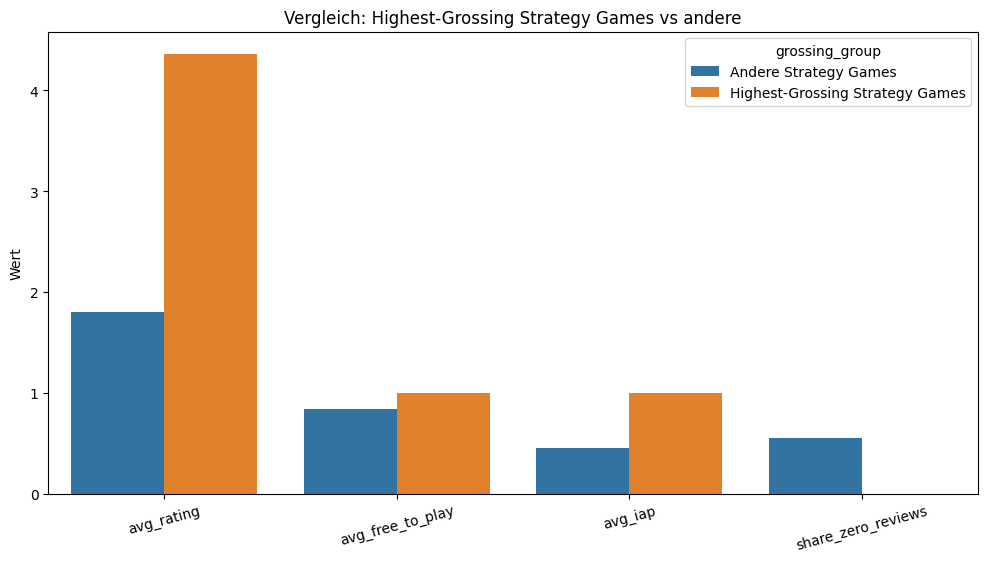

In [21]:
comparison_plot = comparison[[
    "grossing_group",
    "avg_rating",
    "avg_free_to_play",
    "avg_iap",
    "share_zero_reviews"
]].melt(
    id_vars="grossing_group",
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_plot, x="metric", y="value", hue="grossing_group")
plt.title("Vergleich: Highest-Grossing Strategy Games vs andere")
plt.xlabel("")
plt.ylabel("Wert")
plt.xticks(rotation=15)
plt.show()

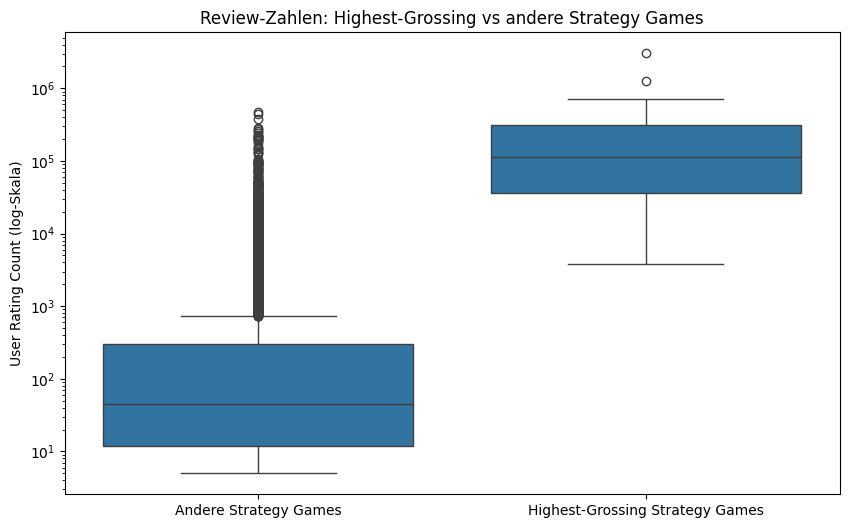

In [22]:
plot_df = strategy_flagged[strategy_flagged["user_rating_count"].notna()].copy()
plot_df = plot_df[plot_df["user_rating_count"] > 0]

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, x="grossing_group", y="user_rating_count")
plt.yscale("log")
plt.title("Review-Zahlen: Highest-Grossing vs andere Strategy Games")
plt.xlabel("")
plt.ylabel("User Rating Count (log-Skala)")
plt.show()

# 3. Ratingverteilung

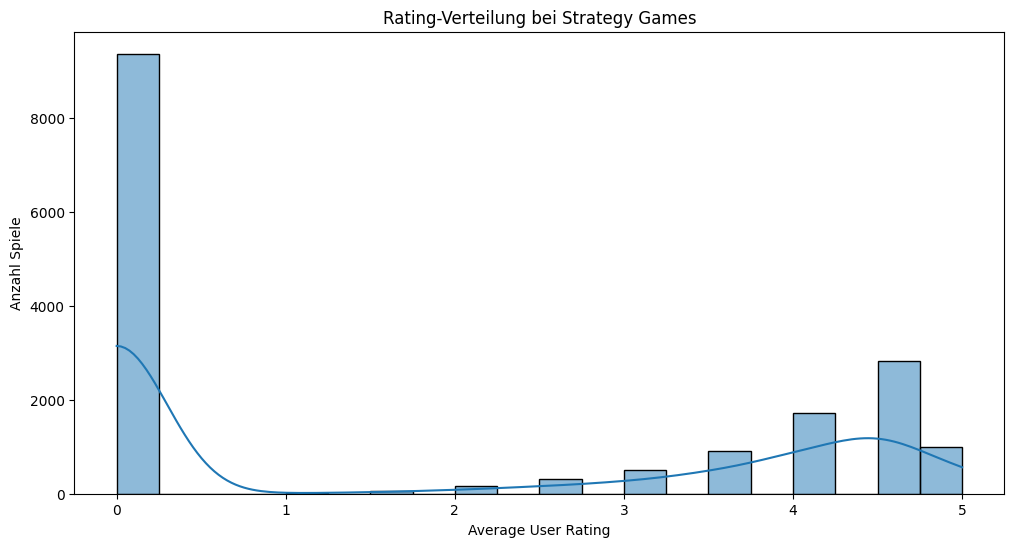

In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(strategy_flagged["average_user_rating"].dropna(), bins=20, kde=True)
plt.title("Rating-Verteilung bei Strategy Games")
plt.xlabel("Average User Rating")
plt.ylabel("Anzahl Spiele")
plt.show()

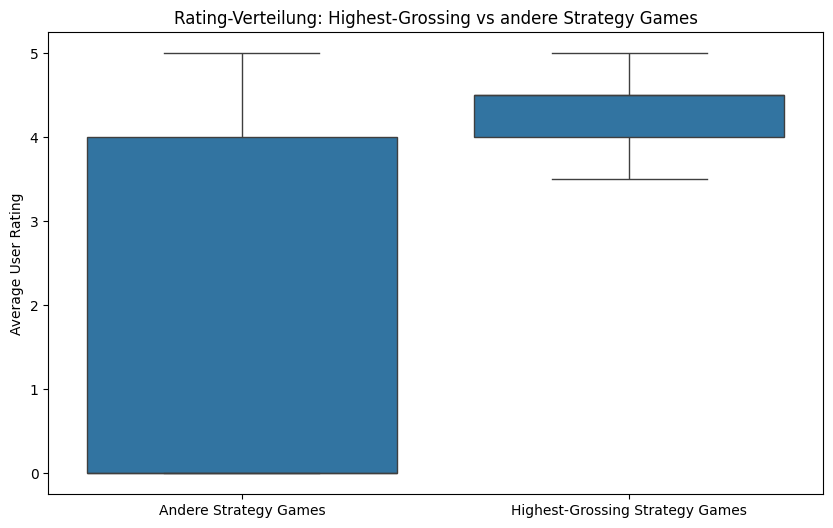

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=strategy_flagged, x="grossing_group", y="average_user_rating")
plt.title("Rating-Verteilung: Highest-Grossing vs andere Strategy Games")
plt.xlabel("")
plt.ylabel("Average User Rating")
plt.show()

# 4. Reviews vs Rating

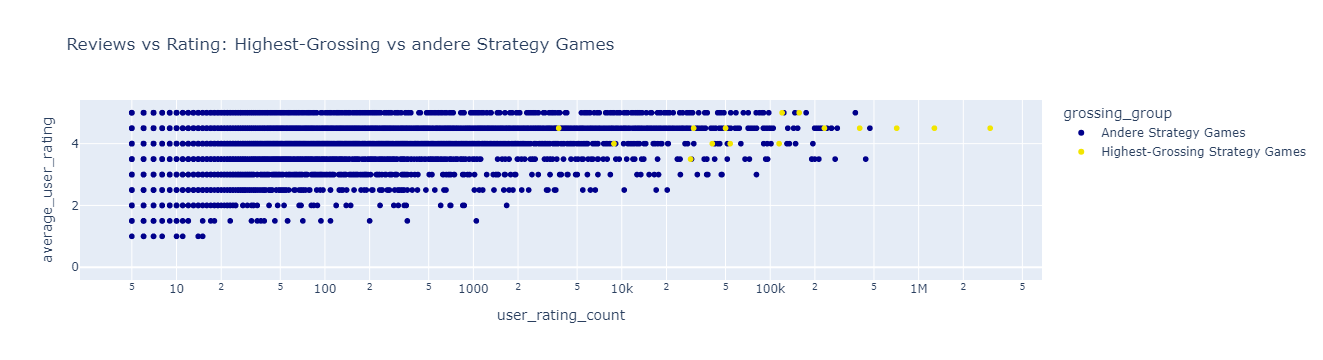

In [25]:
fig = px.scatter(
    strategy_flagged[
        strategy_flagged["user_rating_count"].notna() &
        strategy_flagged["average_user_rating"].notna()
    ],
    x="user_rating_count",
    y="average_user_rating",
    color="grossing_group",
    hover_name="name",
    log_x=True,
    title="Reviews vs Rating: Highest-Grossing vs andere Strategy Games",
    color_discrete_map={
        "Andere Strategy Games": "darkblue",
        "Highest-Grossing Strategy Games": "#f2e500"
    }
)

fig.show()

# 5. Preisstruktur - kostenlos vs kostenpflichtig

### Teile die Spiele in 4 Monetisierungsgruppen auf

- **Kostenlos ohne IAP**
- **Kostenlos mit IAP**
- **Kostenpflichtig ohne IAP**
- **Kostenpflichtig mit IAP**

In [26]:
def monetization_type(row):
    free = row["price"] == 0 if pd.notna(row["price"]) else True
    iap = row["has_in_app_purchases"]

    if free and iap:
        return "Kostenlos mit IAP"
    elif free and not iap:
        return "Kostenlos ohne IAP"
    elif not free and iap:
        return "Kostenpflichtig mit IAP"
    else:
        return "Kostenpflichtig ohne IAP"

strategy_flagged["monetization_type"] = strategy_flagged.apply(monetization_type, axis=1)

In [27]:
monetization_summary = strategy_flagged.groupby("monetization_type").agg(
    avg_rating=("average_user_rating", "mean"),
    median_rating=("average_user_rating", "median"),
    avg_reviews=("user_rating_count", "mean"),
    count_games=("name", "count")
).reset_index()

display(monetization_summary)

,monetization_type,avg_rating,median_rating,avg_reviews,count_games
0,Kostenlos mit IAP,2.485158,3.5,2897.186621,7041
1,Kostenlos ohne IAP,1.136621,0.0,305.382057,7067
2,Kostenpflichtig mit IAP,2.705575,4.0,2212.290941,574
3,Kostenpflichtig ohne IAP,1.539723,0.0,429.598152,2165


## Rating nach Monetasierung

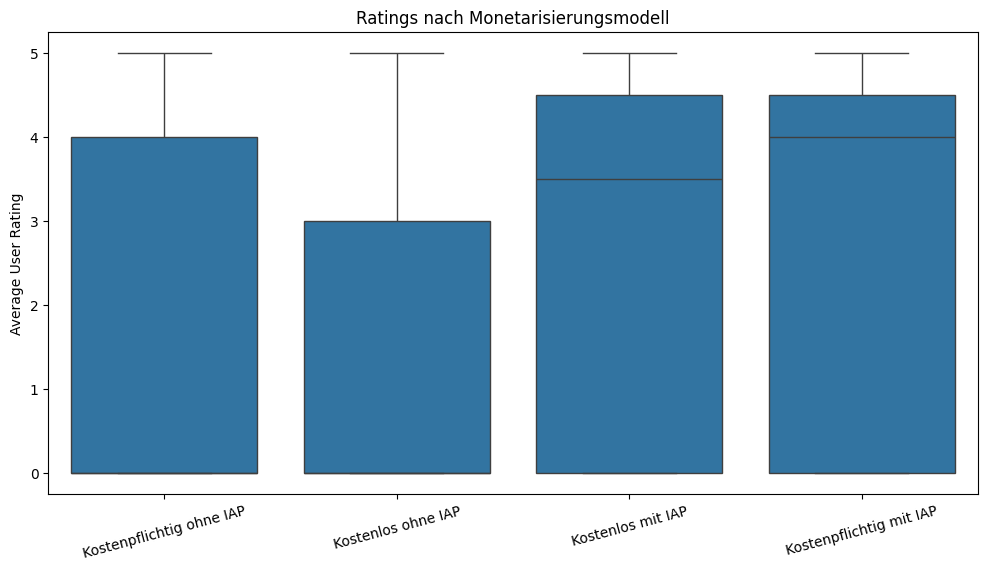

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=strategy_flagged, x="monetization_type", y="average_user_rating")
plt.title("Ratings nach Monetarisierungsmodell")
plt.xlabel("")
plt.ylabel("Average User Rating")
plt.xticks(rotation=15)
plt.show()

# 6. Genre-Analyse

In [29]:
strategy_genres = strategy_flagged.explode("genre_list").copy()
strategy_genres["genre_list"] = strategy_genres["genre_list"].astype(str).str.strip()
strategy_genres = strategy_genres[strategy_genres["genre_list"] != ""]

strategy_genre_rating = (
    strategy_genres.groupby("genre_list")
    .agg(
        avg_rating=("average_user_rating", "mean"),
        game_count=("name", "count")
    )
    .query("game_count >= 20")
    .sort_values("avg_rating", ascending=False)
    .head(15)
    .reset_index()
)

display(strategy_genre_rating)

,genre_list,avg_rating,game_count
0,Role Playing,2.894831,1122
1,Social Networking,2.500000,126
2,Simulation,2.315913,2124
3,Card,2.216095,671
4,Action,2.094268,1989
5,Finance,2.049020,51
6,Board,1.926930,1697
7,News,1.900000,20
8,Entertainment,1.879548,7916
9,Music,1.866071,112


## Genre mit den hächsten Ratings

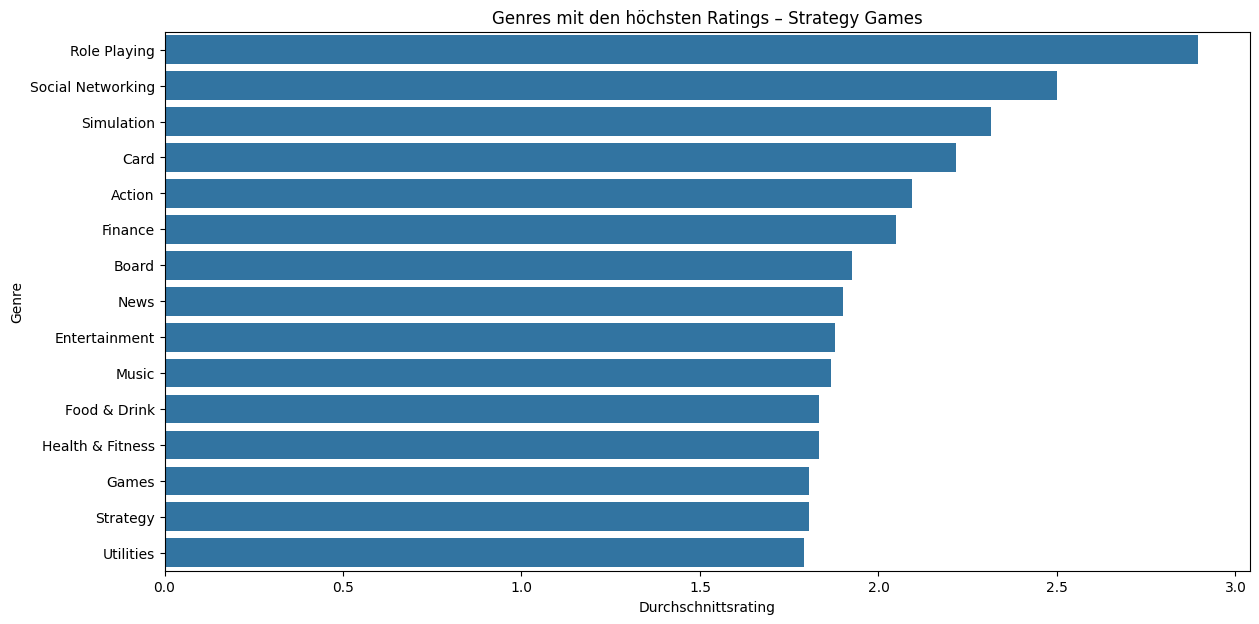

In [30]:
plt.figure(figsize=(14, 7))
sns.barplot(data=strategy_genre_rating, x="avg_rating", y="genre_list")
plt.title("Genres mit den höchsten Ratings – Strategy Games")
plt.xlabel("Durchschnittsrating")
plt.ylabel("Genre")
plt.show()

## Erfolgreichste Genres im Grossing-Datensatz

In [31]:
grossing["genre_list"] = (
    grossing["genre_s"]
    .fillna("")
    .str.split("/")
    .apply(lambda x: [i.strip() for i in x if i.strip() != ""])
)

In [32]:
grossing_genres = grossing.explode("genre_list").copy()
grossing_genres = grossing_genres[grossing_genres["genre_list"].notna()]
grossing_genres = grossing_genres[grossing_genres["genre_list"] != ""]

In [33]:
revenue_col = "revenue_usd_billions" if "revenue_usd_billions" in grossing.columns else "revenue_billion_usd"

grossing_genre_success = (
    grossing_genres.groupby("genre_list")
    .agg(
        avg_revenue=(revenue_col, "mean"),
        game_count=("game", "count")
    )
    .query("game_count >= 2")
    .sort_values("avg_revenue", ascending=False)
    .head(15)
    .reset_index()
)

display(grossing_genre_success)

,genre_list,avg_revenue,game_count
0,Augmented reality,4.343860,2
1,MOBA,3.570700,5
2,Battle royale,3.503054,5
3,Puzzle,2.396413,18
4,RPG,2.232346,16
5,Strategy,2.214238,13
6,MMO,2.136425,4
7,Decoration,1.837333,3
8,MMORPG,1.542528,9
9,Action RPG,1.199750,4


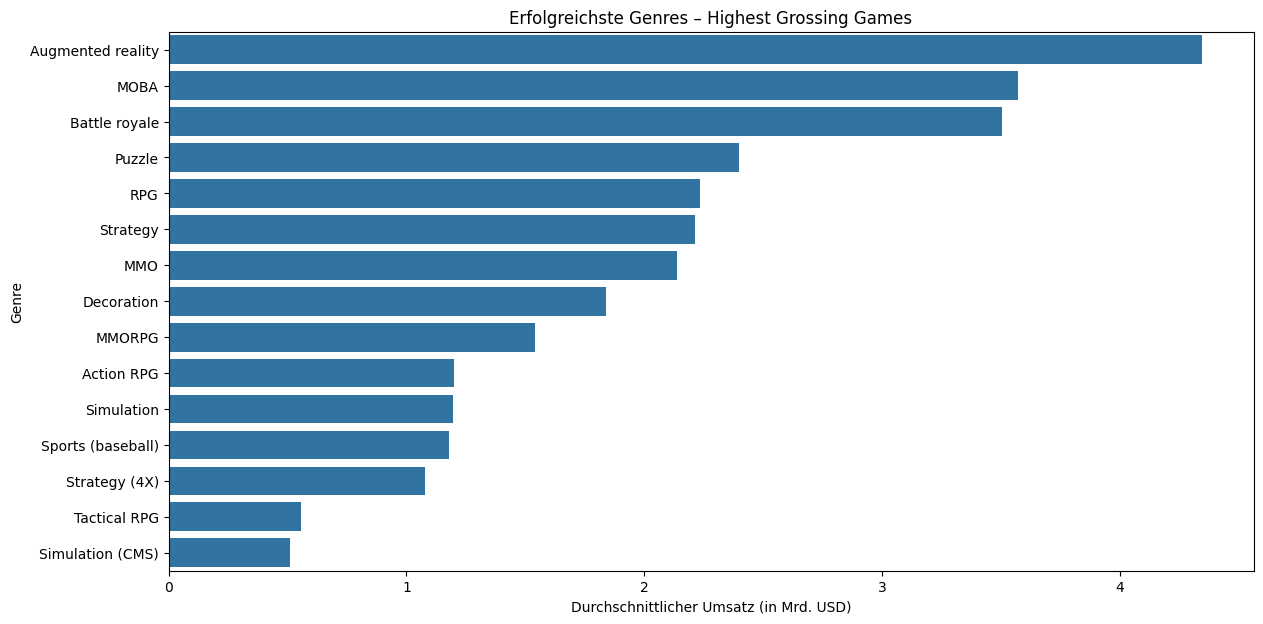

In [34]:
plt.figure(figsize=(14, 7))
sns.barplot(data=grossing_genre_success, x="avg_revenue", y="genre_list")
plt.title("Erfolgreichste Genres – Highest Grossing Games")
plt.xlabel("Durchschnittlicher Umsatz (in Mrd. USD)")
plt.ylabel("Genre")
plt.show()

# 7. Developer und Publisher

In [35]:
def fix_escaped_text(text):
    if pd.isna(text):
        return text
    
    text = str(text)
    
    try:
        return text.encode("utf-8").decode("unicode_escape")
    except:
        return text

In [36]:
strategy_flagged["developer"] = strategy_flagged["developer"].apply(fix_escaped_text)

## Devs mit den meisten Strategy Games

In [37]:
top_developers_count = (
    strategy_flagged.groupby("developer")
    .agg(game_count=("name", "count"))
    .sort_values("game_count", ascending=False)
    .head(15)
    .reset_index()
)

display(top_developers_count)

,developer,game_count
0,Tapps Tecnologia da Informação Ltda.,121
1,Vikash Patel,105
2,"Netsummit Marketing, Inc.",94
3,GabySoft,85
4,"NetSummit Enterprises, Inc.",77
5,Andrew Kudrin,62
6,MmpApps Corp.,61
7,Domyung Kim,57
8,Amy Prizer,46
9,Detention Apps,41


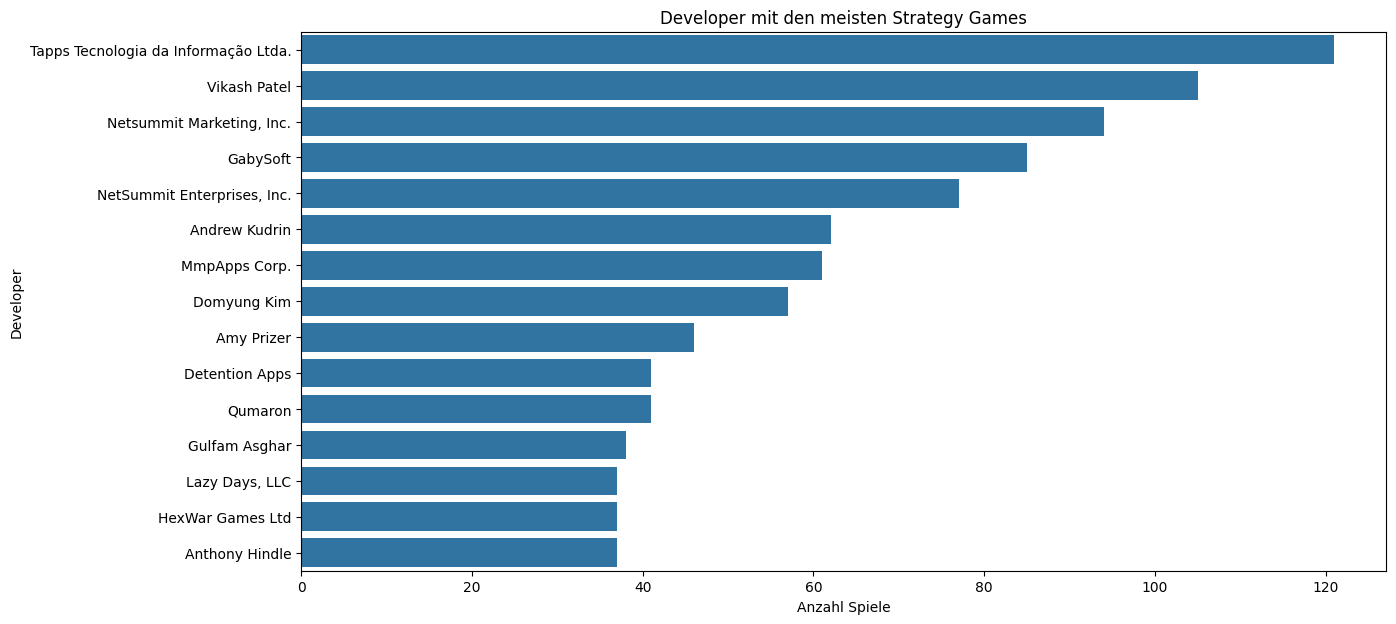

In [38]:
plt.figure(figsize=(14, 7))
sns.barplot(data=top_developers_count, x="game_count", y="developer")
plt.title("Developer mit den meisten Strategy Games")
plt.xlabel("Anzahl Spiele")
plt.ylabel("Developer")
plt.show()

## Ergolgreichste Publisher

In [39]:
top_publishers = (
    grossing.groupby("publisher_s")
    .agg(
        total_revenue=("revenue_usd_billions" if "revenue_usd_billions" in grossing.columns else "revenue_billion_usd", "sum"),
        game_count=("game", "count")
    )
    .sort_values("total_revenue", ascending=False)
    .head(15)
    .reset_index()
)

display(top_publishers)

,publisher_s,total_revenue,game_count
0,Supercell (Tencent),14.800000,5
1,Tencent Games,14.667500,1
2,Mixi,10.000000,1
3,King (Activision Blizzard),9.814000,4
4,Tencent Games / Krafton / VNG Games,9.000000,1
5,GungHo Online Entertainment,8.578340,1
6,NetEase,8.174270,4
7,Niantic / The Pokémon Company,7.760000,1
8,Playrix,7.139700,4
9,Aniplex (Sony Music Entertainment Japan),6.300000,1


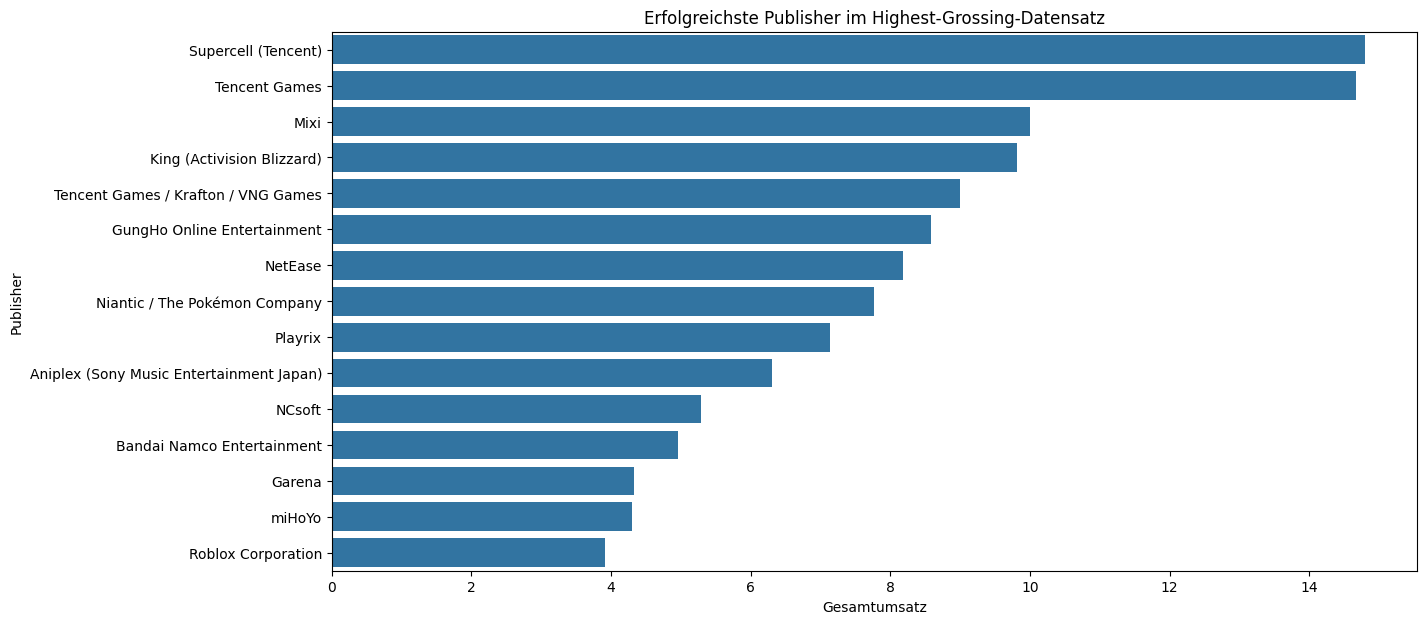

In [40]:
plt.figure(figsize=(14, 7))
sns.barplot(data=top_publishers, x="total_revenue", y="publisher_s")
plt.title("Erfolgreichste Publisher im Highest-Grossing-Datensatz")
plt.xlabel("Gesamtumsatz")
plt.ylabel("Publisher")
plt.show()

# 8. Dashboard

In [41]:
def fix_text(text):
    if pd.isna(text):
        return text

    text = str(text)

    try:
        text = text.encode("utf-8").decode("unicode_escape")
    except:
        pass

    try:
        text = text.encode("latin1").decode("utf-8")
    except:
        pass

    return text

def parse_genre_list(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        items = value
    else:
        value = str(value).strip()

        if value == "":
            return []

        if value.startswith("[") and value.endswith("]"):
            try:
                parsed = ast.literal_eval(value)
                if isinstance(parsed, list):
                    items = parsed
                else:
                    items = [value]
            except:
                items = [value]
        elif "," in value:
            items = value.split(",")
        elif "/" in value:
            items = value.split("/")
        else:
            items = [value]

    cleaned = []
    for item in items:
        item = fix_text(item)
        item = str(item).strip()
        if item != "":
            cleaned.append(item)

    return list(dict.fromkeys(cleaned))

In [42]:
# Textfelder bereinigen
for col in ["name", "developer", "publisher_s", "genre_s", "genres"]:
    if col in strategy_flagged.columns:
        strategy_flagged[col] = strategy_flagged[col].apply(fix_text)

# Strategy-Genres sauber neu bauen
strategy_flagged["genre_list_clean"] = strategy_flagged["genres"].apply(parse_genre_list)

# Preis-Typ
strategy_flagged["price_type"] = np.where(
    strategy_flagged["price"].fillna(0) == 0,
    "Kostenlos",
    "Kostenpflichtig"
)

## Strategy-Dashbaord

In [43]:
dashboard_df = strategy_flagged.copy()

dashboard_df["genre_display"] = dashboard_df["genre_list_clean"].apply(
    lambda x: ", ".join(x) if isinstance(x, list) else ""
)
strategy_genre_options = ["Alle"] + sorted({
    genre
    for genres in dashboard_df["genre_list_clean"]
    for genre in genres
})

@interact(
    genre=widgets.Dropdown(
        options=strategy_genre_options,
        value="Alle",
        description="Genre"
    ),
    price_type=widgets.Dropdown(
        options=["Alle", "Kostenlos", "Kostenpflichtig"],
        value="Alle",
        description="Preis"
    ),
    grossing_only=widgets.Checkbox(
        value=False,
        description="Nur Highest Grossing"
    ),
    top_n=widgets.IntSlider(
        value=15,
        min=5,
        max=30,
        step=1,
        description="Top N"
    )
)
def strategy_dashboard_view(genre, price_type, grossing_only, top_n):
    df = dashboard_df.copy()

    if genre != "Alle":
        df = df[df["genre_list_clean"].apply(lambda x: genre in x)]

    if price_type != "Alle":
        df = df[df["price_type"] == price_type]

    if grossing_only:
        df = df[df["is_highest_grossing"] == 1]

    df = df[df["user_rating_count"].notna()]
    df = df.sort_values("user_rating_count", ascending=False).head(top_n)

    cols = [
    "name",
    "developer",
    "genre_display",
    "average_user_rating",
    "user_rating_count",
    "price",
    "price_type",
    "is_highest_grossing",
    ]

    extra_cols = [c for c in ["revenue_billion_usd"] if c in df.columns]

    display(df[cols + extra_cols])
    

    if len(df) > 0:
        fig = px.bar(
            df.sort_values("user_rating_count"),
            x="user_rating_count",
            y="name",
            color="average_user_rating",
            orientation="h",
            title="Strategy-Dashboard: Top Games nach Filter"
        )
        fig.show()

interactive(children=(Dropdown(description='Genre', options=('Alle', 'Action', 'Adventure', 'Animals & Nature'…

In [46]:
# Textfelder in grossing bereinigen
for col in ["game", "publisher_s", "genre_s"]:
    if col in grossing.columns:
        grossing[col] = grossing[col].apply(fix_text)

# Grossing-Genres sauber aus genre_s bauen
grossing["genre_list_clean"] = grossing["genre_s"].apply(parse_genre_list)

# Optionen für Dropdown bauen
grossing_genre_options = sorted({
    genre
    for genres in grossing["genre_list_clean"].dropna()
    for genre in genres
    if pd.notna(genre)
})

In [48]:
@interact(
    genre=widgets.Dropdown(
        options=["Alle"] + grossing_genre_options,
        value="Alle",
        description="Genre"
    ),
    top_n=widgets.IntSlider(
        value=10,
        min=5,
        max=20,
        step=1,
        description="Top N"
    )
)
def grossing_genre_view(genre, top_n):
    df = grossing.copy()

    if genre != "Alle":
        df = df[df["genre_list_clean"].apply(lambda x: genre in x)]

    df = df.sort_values(revenue_col, ascending=False).head(top_n)

    display(df[["game", revenue_col, "publisher_s", "genre_s", "initial_release"]])

    if len(df) > 0:
        fig = px.bar(
            df.sort_values(revenue_col),
            x=revenue_col,
            y="game",
            color="publisher_s",
            orientation="h",
            title="Top Highest-Grossing Games nach Genre-Filter"
        )
        fig.show()

interactive(children=(Dropdown(description='Genre', options=('Alle', 'ARPG', 'Action RPG', 'Adventure', 'Augme…